# Assignment 1: Breast Cancer Classification

Author: Tobias Beekmans  
Master ICT – Software Engineering  
DataOps Specialization Project – Individual Assignment  
Submission Date: 15.03.2026

In [1]:
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.model_selection import StratifiedKFold, cross_val_score

In [2]:
data_dir = Path("../data/processed")

X_train = pd.read_csv(data_dir / "X_train_scaled.csv")
X_test = pd.read_csv(data_dir / "X_test_scaled.csv")
y_train = pd.read_csv(data_dir / "y_train.csv").squeeze("columns")
y_test = pd.read_csv(data_dir / "y_test.csv").squeeze("columns")

# 4. Modeling

The modeling phase includes selecting appropriate modeling techniques, defining a test design, building models, and assessing their performance. [1]

In this project, this phase includes model selection, baseline comparison, model training, and assessment of predictive performance.

## 4.1 Model Selection

Several algorithms are evaluated to compare different modeling approaches for the breast cancer classification task. Comparative studies using the Wisconsin Breast Cancer dataset report strong predictive performance for classical machine learning models such as logistic regression, support vector machines, random forests, and k-nearest neighbors. In particular, comparison studies show that these algorithms consistently achieve classification accuracies above 95% on the dataset, making them suitable benchmark models for breast cancer diagnosis tasks. [2]

The selected models represent different machine learning paradigms:

- **Logistic Regression**: A linear probabilistic model commonly used for binary classification
- **Support Vector Machine (SVM)**: A margin-based classifier that identifies a decision boundary separating the classes
- **Random Forest**: An ensemble method based on multiple decision trees that can capture non-linear relationships
- **K-Nearest Neighbors (KNN)**: A distance-based classifier that assigns labels based on nearby observations

In addition, a Dummy Classifier is used as a naive baseline that always predicts the majority class.

## 4.2 Test Design

The dataset was previously divided into training and test subsets using an 80/20 split. All models are trained on the same training dataset and evaluated on the same test dataset to ensure a fair comparison.

Model performance is assessed using several standard classification metrics that capture different aspects of predictive performance [3]:

- **Accuracy**: Proportion of correctly classified observations
- **Precision**: Proportion of positive predictions that are correct
- **Recall**: Proportion of actual positive cases that are correctly identified
- **F1-Score**: Harmonic mean of precision and recall

Using multiple evaluation metrics provides a more complete assessment of model performance than accuracy alone, particularly in medical classification tasks where false negatives are important.

Because the dataset encodes benign cases as the positive class (target=1), the reported precision, recall, and F1-scores primarily reflect performance with respect to benign predictions. False negatives for malignant tumors are therefore examined in more detail during the evaluation phase using confusion matrices and ROC analysis.

## 4.3 Baseline Model

A baseline classifier is used to provide a simple reference point for model comparison.  

The Dummy Classifier predicts the `most frequent` class observed in the training data. This model does not learn patterns from the predictor variables. Instead it represents the minimum level of performance that more advanced machine learning models should exceed.

In [3]:
baseline_model = DummyClassifier(strategy='most_frequent')
baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_precision = precision_score(y_test, y_pred_baseline)
baseline_recall = recall_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)

print("Baseline Model Performance")
print("Accuracy:", round(baseline_accuracy, 4))
print("Precision:", round(baseline_precision, 4))
print("Recall:", round(baseline_recall, 4))
print("F1-score:", round(baseline_f1, 4))

Baseline Model Performance
Accuracy: 0.6316
Precision: 0.6316
Recall: 1.0
F1-score: 0.7742


The baseline classifier achieves an accuracy of 0.6316 on the test dataset. This value corresponds to the proportion of the majority class, since the model always predicts benign cases.

Although the recall for the majority class is 1.0, the model fails to identify malignant tumors because it predicts only benign outcomes. Consequently, the classifier does not capture any relationship between the diagnostic features and the tumor diagnosis.

The baseline therefore represents a minimal performance benchmark that meaningful machine learning models should clearly outperform.

## 4.4 Logistic Regression

Logistic Regression is a widely used linear model for binary classification. The model estimates the probability that an observation belongs to a particular class using a logistic function. Logistic Regression provides an interpretable baseline model and often performs well on standardized tabular datasets. [4]

The parameter `max_iter=1000` increases the maximum number of iterations allowed for the optimization algorithm. This helps ensure convergence during model training, particularly when the dataset contains multiple correlated features.

In [4]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

log_accuracy = accuracy_score(y_test, y_pred_log)
log_precision = precision_score(y_test, y_pred_log)
log_recall = recall_score(y_test, y_pred_log)
log_f1 = f1_score(y_test, y_pred_log)

print("Logistic Regression Performance")
print("Accuracy:", round(log_accuracy, 4))
print("Precision:", round(log_precision, 4))
print("Recall:", round(log_recall, 4))
print("F1-score:", round(log_f1, 4))

Logistic Regression Performance
Accuracy: 0.9825
Precision: 0.9861
Recall: 0.9861
F1-score: 0.9861


The Logistic Regression model achieves very strong classification performance with an accuracy of 0.9825 on the test dataset. This result indicates that the diagnostic features provide strong predictive information for distinguishing between malignant and benign tumors. The precision, recall, and F1-score are all very high and closely aligned, indicating that the model performs consistently across different classification perspectives rather than achieving high accuracy through class imbalance alone.

The strong performance of a linear classifier suggests that the two classes are largely separable in the feature space. These results are consistent with previous studies that report strong performance of logistic regression on the Wisconsin Breast Cancer dataset, including regularized variants. [4]

## 4.5 Support Vector Machine (SVM)

Support Vector Machines (SVM) are supervised learning algorithms that classify data by finding a decision boundary that maximizes the margin between classes. The model identifies a hyperplane that separates observations belonging to different categories while maximizing the distance between the closest training samples.

SVM models are particularly effective for high-dimensional datasets and are widely used for medical classification problems. When the relationship between variables is not perfectly linear, kernel functions can be used to map the data into a higher-dimensional feature space where separation becomes easier.

The SVM model uses an `RBF` kernel, which allows the classifier to capture non-linear decision boundaries. The parameter `C` controls the trade-off between maximizing the margin and minimizing classification errors, while `gamma` determines the influence of individual training samples on the decision boundary.

In [5]:
svm_model = SVC(kernel='rbf', C=1, gamma='scale', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)

print("SVM Performance")
print("Accuracy:", round(svm_accuracy, 4))
print("Precision:", round(svm_precision, 4))
print("Recall:", round(svm_recall, 4))
print("F1-score:", round(svm_f1, 4))

SVM Performance
Accuracy: 0.9825
Precision: 0.9861
Recall: 0.9861
F1-score: 0.9861


The Support Vector Machine model achieves very strong predictive performance with an accuracy of 0.9825 on the test dataset. The high precision, recall, and F1-score indicate that the classifier identifies both benign and malignant cases with very few misclassifications. The high precision and recall indicate that the model is effective both in avoiding false positives and in identifying actual positive cases, resulting in a balanced F1-score.

This strong performance is consistent with previous studies reporting that SVM often performs among the strongest classical classifiers on the Wisconsin Breast Cancer dataset. [5]

## 4.6 Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees using a bagging strategy. Each tree is trained on a random subset of the training data and predictor variables, and the final prediction is obtained by aggregating the outputs of all trees. 

This ensemble approach reduces the risk of overfitting and improves generalization performance compared to individual decision trees. Random Forest models are particularly well suited for tabular datasets because they can capture non-linear relationships and interactions between variables.

The parameter `n_estimators=100` defines the number of trees in the ensemble. Increasing the number of trees generally improves model stability but also increases computational cost.

In [6]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("Accuracy:", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall:", round(rf_recall, 4))
print("F1-score:", round(rf_f1, 4))

Random Forest Performance
Accuracy: 0.9561
Precision: 0.9589
Recall: 0.9722
F1-score: 0.9655


The Random Forest model achieves strong predictive performance with an accuracy of 0.9561 on the test dataset. The precision, recall, and F1-score remain high, indicating that the model performs reliably across both classes, even though its overall accuracy is slightly lower than that of Logistic Regression and SVM.

Ensemble models are particularly useful because they combine the predictions of multiple decision trees, which often improves model stability and robustness. Previous studies using the Wisconsin Breast Cancer dataset report strong predictive performance for Random Forest classifiers and demonstrate that ensemble methods are effective for breast cancer diagnosis tasks. [6]

### Feature Importance

The feature importance analysis indicates which diagnostic measurements receive the highest importance scores in the Random Forest model.

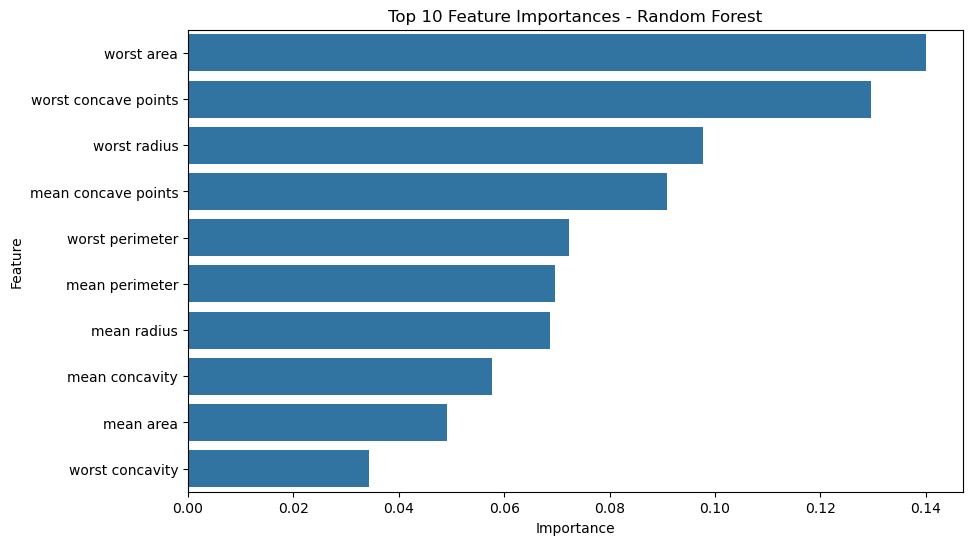

In [7]:
feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

top_features = feature_importances.head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_features.values, y=top_features.index)

plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

The most influential predictors include  `worst area`, `worst concave points`, `worst radius`, and `mean concave points`. These features describe geometric characteristics of the cell nuclei and reflect structural differences between malignant and benign tumors.

In particular, measurements related to tumor size and boundary irregularities appear to be highly informative for the classification task. This observation is consistent with previous research on the Wisconsin Breast Cancer dataset, which reports that morphological features of cell nuclei provide strong predictive information for breast cancer diagnosis. [6]

## 4.7 K-Nearest Neighbors (KNN)

The K-Nearest Neighbors (KNN) algorithm is a non-parametric classification method that assigns class labels based on the labels of the nearest training samples in the feature space. The algorithm measures the distance between observations and predicts the class of a new instance according to the majority class among its k closest neighbors.

KNN is a simple yet effective algorithm for classification tasks. Because predictions are based directly on the training data, the algorithm can capture complex decision boundaries without explicitly learning a parametric model.

The parameter `n_neighbors=5` determines how many neighboring observations are considered when assigning a class label to a new sample. Smaller values allow the model to capture more local patterns, while larger values produce smoother decision boundaries.

In [8]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)

print("KNN Performance")
print("Accuracy:", round(knn_accuracy, 4))
print("Precision:", round(knn_precision, 4))
print("Recall:", round(knn_recall, 4))
print("F1-score:", round(knn_f1, 4))

KNN Performance
Accuracy: 0.9561
Precision: 0.9589
Recall: 0.9722
F1-score: 0.9655


The K-Nearest Neighbors model achieves an accuracy of 0.9561 on the test dataset. The precision, recall, and F1-score remain strong, indicating that the model performs reliably despite being somewhat less accurate than the best-performing classifiers.

The model classifies observations based on the similarity of diagnostic measurements in the feature space. Because the predictor variables were standardized during the data preparation phase, all features contribute equally to the distance calculations used by the KNN algorithm.

The obtained performance is slightly lower than the results achieved by Logistic Regression and SVM, but still clearly exceeds the baseline classifier. This indicates that tumor samples with similar morphological characteristics tend to cluster together in the feature space, allowing distance-based methods such as KNN to distinguish between benign and malignant cases effectively.

Previous studies applying KNN to the Wisconsin Breast Cancer dataset report comparable classification accuracies, typically above 95% depending on the choice of neighborhood size and preprocessing strategy. [7]

## 4.8 Cross-Validation

To obtain a more robust estimate of model performance, stratified k-fold cross-validation is applied on the training dataset.

Cross-validation repeatedly splits the training data into smaller training and validation subsets, allowing the model to be trained and evaluated multiple times. This approach reduces the dependence of performance estimates on a single train–test split and provides a more reliable indication of model stability. [8]

Because the dataset is relatively small, cross-validation helps assess whether the models consistently achieve strong performance across different data partitions.


In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "SVM": svm_model,
    "KNN": knn_model
}

cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    cv_results.append({
        "Model": name,
        "CV Accuracy Mean": scores.mean(),
        "CV Accuracy Std": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df.sort_values("CV Accuracy Mean", ascending=False)

,Model,CV Accuracy Mean,CV Accuracy Std
0,Logistic Regression,0.978022,0.009829
2,SVM,0.967033,0.015541
1,Random Forest,0.962637,0.017855
3,KNN,0.960440,0.011207


The cross-validation results confirm that all evaluated models achieve consistently strong classification performance across different training and validation splits.

Logistic Regression shows the highest mean accuracy (97.8%) and the lowest variability among the evaluated models, indicating stable predictive performance across the cross-validation folds. Support Vector Machine also demonstrates strong performance with a slightly lower mean accuracy.

Random Forest and K-Nearest Neighbors achieve slightly lower cross-validation accuracy scores, but still maintain strong classification performance above 96%.

The relatively small standard deviations across the folds suggest that the models perform consistently and that the results are not strongly dependent on a particular data partition.

The cross-validation results are consistent with the test set performance observed earlier, suggesting that the selected models generalize well and do not appear to suffer from significant overfitting.


## 4.9 Model Assessment

The classification results of the evaluated models are summarized below.

In [10]:
results_df = pd.DataFrame({

    "Model": [
        "Baseline",
        "Logistic Regression",
        "Random Forest",
        "SVM",
        "KNN"
    ],

    "Accuracy": [
        baseline_accuracy,
        log_accuracy,
        rf_accuracy,
        svm_accuracy,
        knn_accuracy
    ],

    "Precision": [
        baseline_precision,
        log_precision,
        rf_precision,
        svm_precision,
        knn_precision
    ],

    "Recall": [
        baseline_recall,
        log_recall,
        rf_recall,
        svm_recall,
        knn_recall
    ],

    "F1 Score": [
        baseline_f1,
        log_f1,
        rf_f1,
        svm_f1,
        knn_f1
    ]
})

results_df = results_df.sort_values("Accuracy", ascending=False)
results_df.reset_index(drop=True, inplace=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111
1,SVM,0.982456,0.986111,0.986111,0.986111
2,Random Forest,0.956140,0.958904,0.972222,0.965517
3,KNN,0.956140,0.958904,0.972222,0.965517
4,Baseline,0.631579,0.631579,1.000000,0.774194


All machine learning models substantially outperform the baseline classifier, indicating that the diagnostic features extracted from the breast cell nuclei contain strong predictive information for distinguishing benign and malignant tumors.

Among the evaluated models, Logistic Regression and Support Vector Machine achieve the highest performance, both reaching an accuracy of approx. 98% on the test dataset. The high precision, recall, and F1-scores indicate that these models correctly identify most malignant and benign cases with very few misclassifications.

The Random Forest and K-Nearest Neighbors models also demonstrate strong predictive performance, achieving accuracies above 95%, but slightly lower than the linear models. This suggests that while non-linear and distance-based methods perform well on the dataset, they do not provide a substantial improvement over simpler models.

One possible explanation is that the diagnostic features in the Wisconsin Breast Cancer dataset allow the two classes to be separated relatively well in the feature space. In such cases, linear classifiers such as Logistic Regression can already achieve very strong predictive performance.

Considering both predictive accuracy and model interpretability, **Logistic Regression can be regarded as a particularly suitable model for this classification task**. Linear models provide coefficients that can be interpreted in relation to the diagnostic features, which is beneficial in medical decision support systems where transparency is important.

The results confirm that classical machine learning models are capable of achieving very high classification accuracy for breast cancer diagnosis when applied to the Wisconsin Breast Cancer dataset.

## References

[1] IBM Corporation (2011): *IBM SPSS Modeler CRISP-DM Guide*

[2] Rovshenov, A.; Peker, S. (2022): *Performance Comparison of Different Machine Learning Techniques for Early Prediction of Breast Cancer using Wisconsin Breast Cancer Dataset*

[3] Müller, A. C.; Guido, S. (2016): *Introduction to Machine Learning with Python*

[4] Vinoci, K. L. (2023): *Wisconsin Breast Cancer Detection Using L1 Logistic Regression*

[5] Patel, K. et al. (2025): *Developing Machine Learning Models to Detect Breast Cancer*

[6] Ono, Y.; Mitani, Y. (2022): *Evaluation of feature extraction methods with ensemble learning for breast cancer classification*

[7] Filani, A.; Arogundade, S. (2024): *Optimized Breast Cancer Prediction Using Machine Learning Algorithms*

[8] James, G.; Witten, D.; Hastie, T.; Tibshirani, R. (2023): *An Introduction to Statistical Learning with Applications in Python*